In [ ]:
%pip install ipykernel

In [1]:
from pathlib import Path

image_paths = list(Path("../data/raw").glob("*"))

print("Total images:", len(image_paths))
# print(Path.cwd())

Total images: 51301


check images formats

In [2]:
from collections import Counter

formats = [p.suffix.lower() for p in image_paths]

Counter(formats)

Counter({'.jpg': 51301})

detect corrupt images

In [3]:
from PIL import Image

corrupted = []

for path in image_paths:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


checking images sizes

In [4]:
sizes = []

for path in image_paths:
    img = Image.open(path)
    sizes.append(img.size)

In [5]:
sizes[:5]

[(1721, 1244), (1720, 1286), (1557, 1044), (1557, 1039), (1570, 1050)]

In [12]:
Counter(sizes)

Counter({(1712, 1244): 8,
         (1712, 1245): 5,
         (1582, 1154): 4,
         (911, 670): 3,
         (1108, 734): 3,
         (1077, 855): 3,
         (954, 900): 3,
         (876, 572): 3,
         (525, 519): 3,
         (541, 519): 3,
         (888, 922): 3,
         (1121, 796): 3,
         (1217, 1080): 3,
         (437, 636): 3,
         (1167, 899): 3,
         (566, 382): 3,
         (1524, 1267): 2,
         (1528, 1364): 2,
         (1497, 1322): 2,
         (1194, 3140): 2,
         (624, 734): 2,
         (612, 731): 2,
         (1191, 925): 2,
         (1192, 920): 2,
         (1188, 1173): 2,
         (1213, 1029): 2,
         (1222, 1168): 2,
         (1357, 1492): 2,
         (973, 743): 2,
         (1666, 1226): 2,
         (1666, 1224): 2,
         (708, 689): 2,
         (687, 690): 2,
         (1578, 1564): 2,
         (487, 480): 2,
         (482, 480): 2,
         (474, 477): 2,
         (725, 761): 2,
         (1364, 1196): 2,
         (672, 640): 2,
  

RGB vs Grayscale

In [6]:
modes = []

for path in image_paths:
    img = Image.open(path)
    modes.append(img.mode)

Counter(modes)

Counter({'RGB': 51301})

Random Visualization

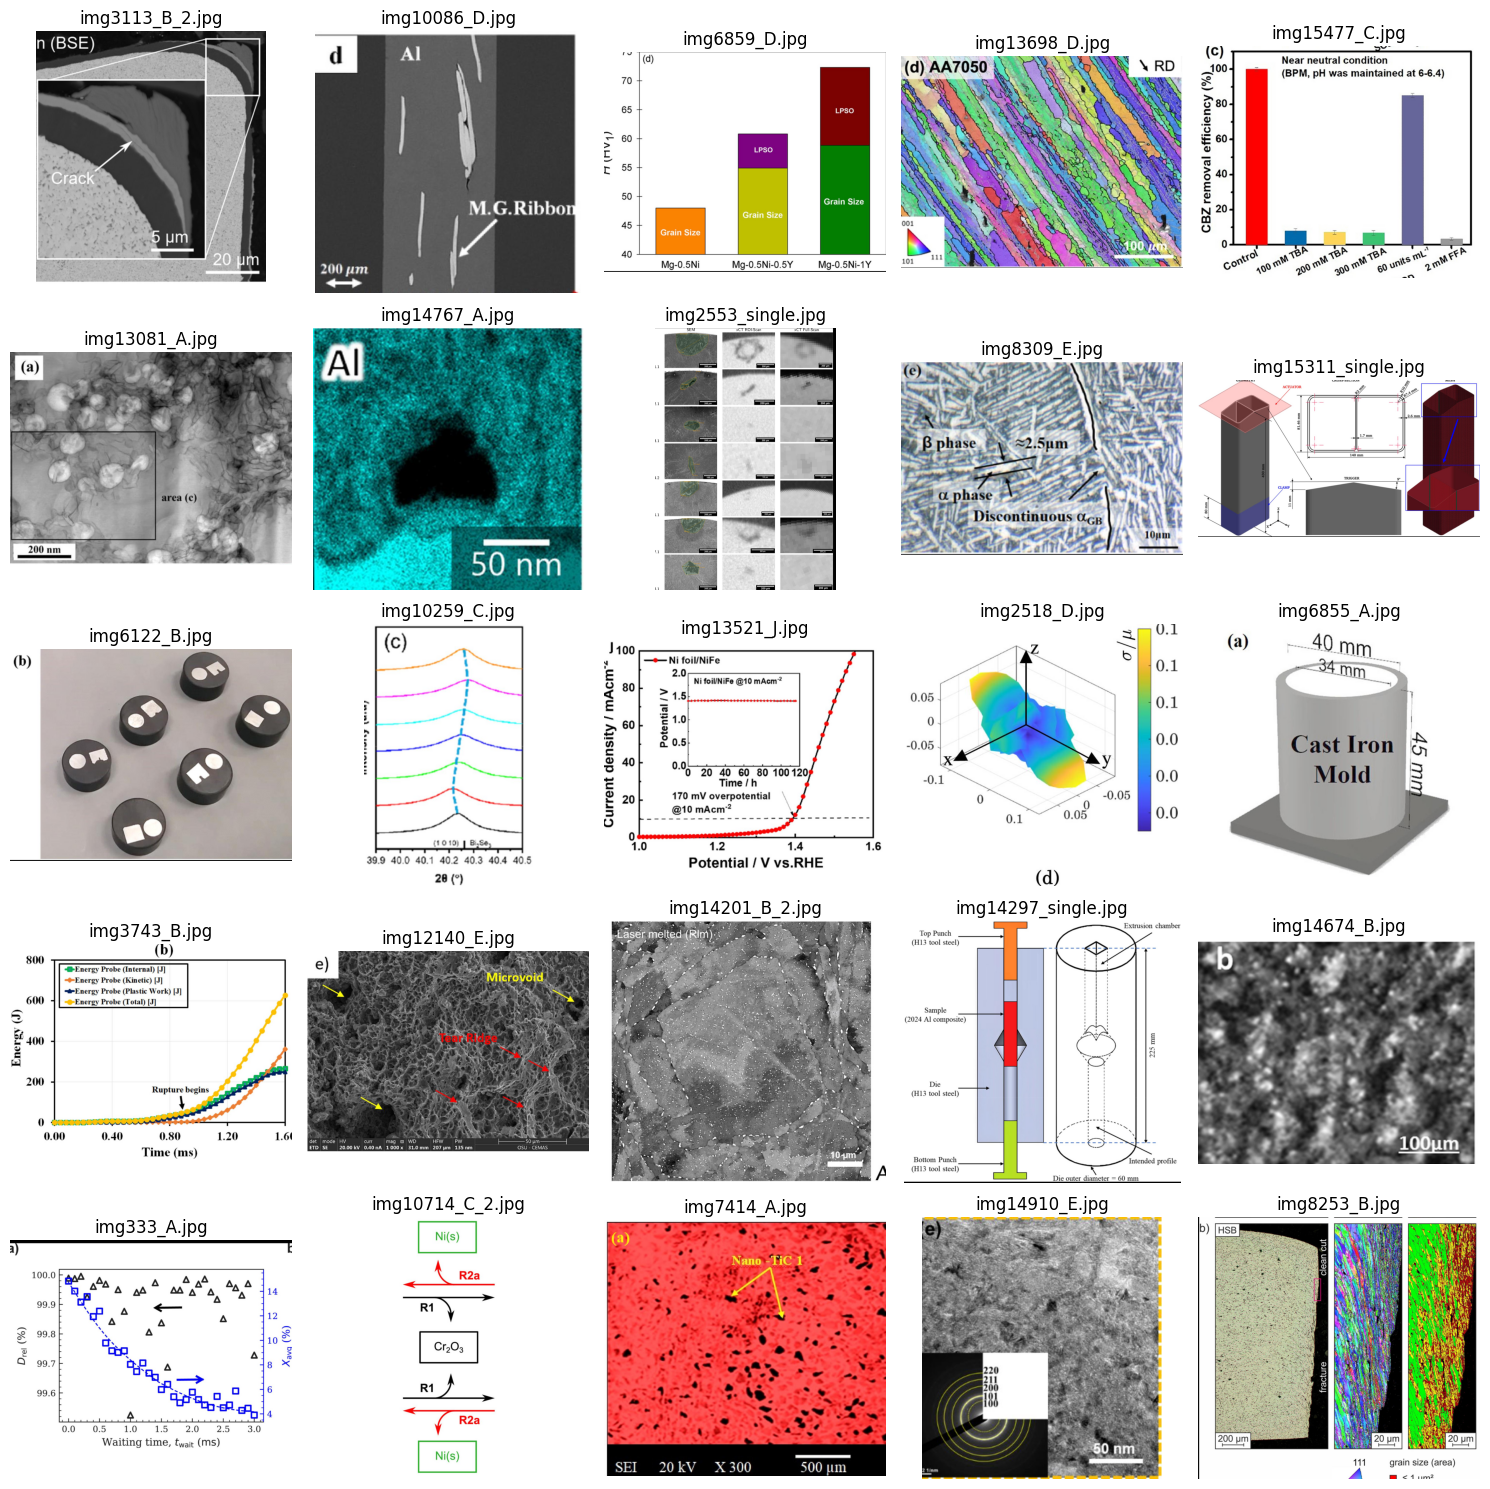

In [7]:
import matplotlib.pyplot as plt
import random

sample = random.sample(image_paths, 25)

fig, axes = plt.subplots(5,5, figsize=(15,15))

for ax, path in zip(axes.flatten(), sample):
    img = Image.open(path)
    ax.imshow(img, cmap='gray')
    ax.set_title(path.name)
    ax.axis('off')

plt.tight_layout()
plt.show()

Create Metadata CSV

In [8]:
import pandas as pd

records = []

for path in image_paths:
    try:
        img = Image.open(path)

        records.append({
            'path': str(path),
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'format': img.format
        })

    except:
        pass

metadata = pd.DataFrame(records)

metadata.to_csv('../data/metadata/metadata.csv', index=False)

duplicate detection

In [9]:
import imagehash
from PIL import Image

hashes = {}
duplicates = []

for path in image_paths:

    try:
        img = Image.open(path)

        # perceptual hash
        h = imagehash.average_hash(img)

        # image size
        size = img.size

        # combine hash + size
        key = (h, size)

        if key in hashes:

            duplicates.append((path, hashes[key]))

        else:
            hashes[key] = path

    except Exception as e:
        print(f"Error with {path}: {e}")

In [10]:
len(duplicates)

3531

check and confirm the duplicates

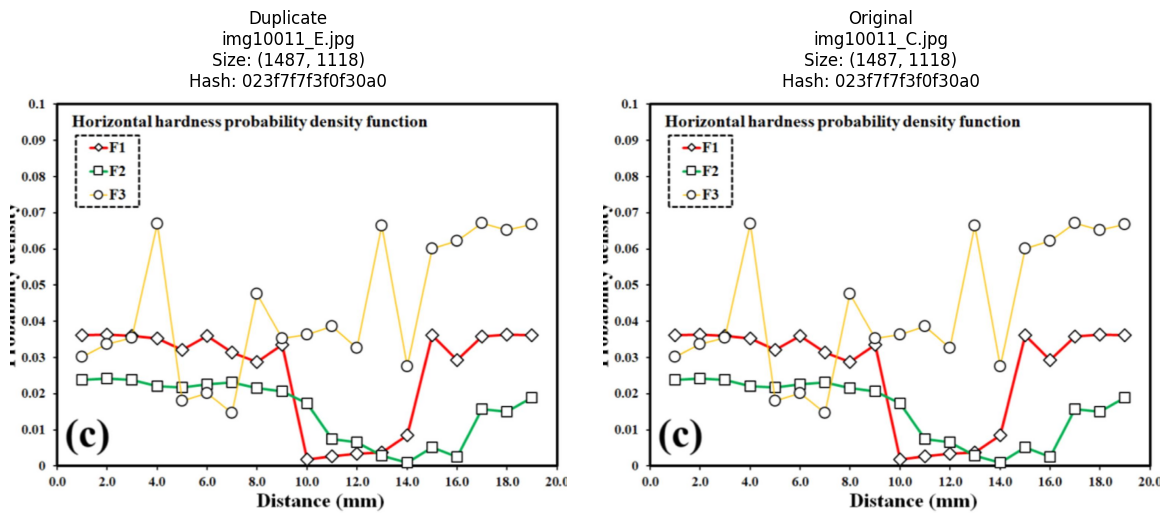

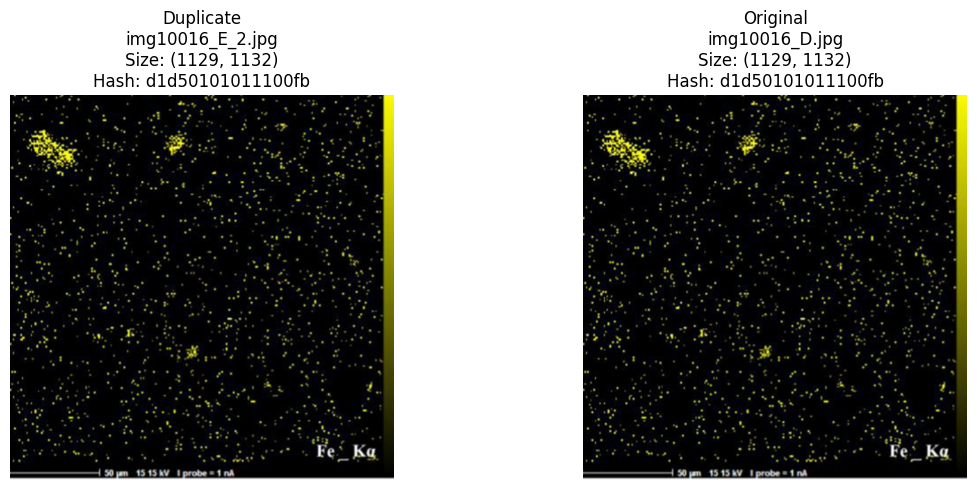

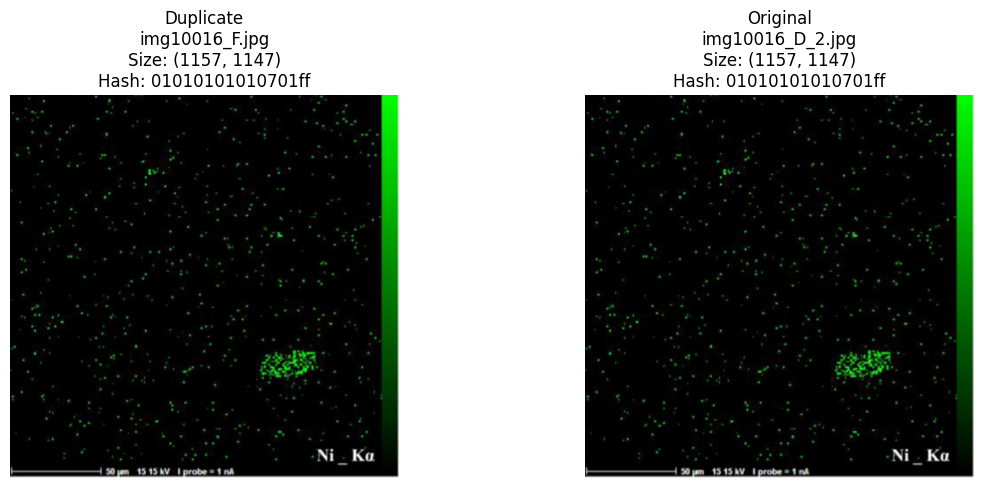

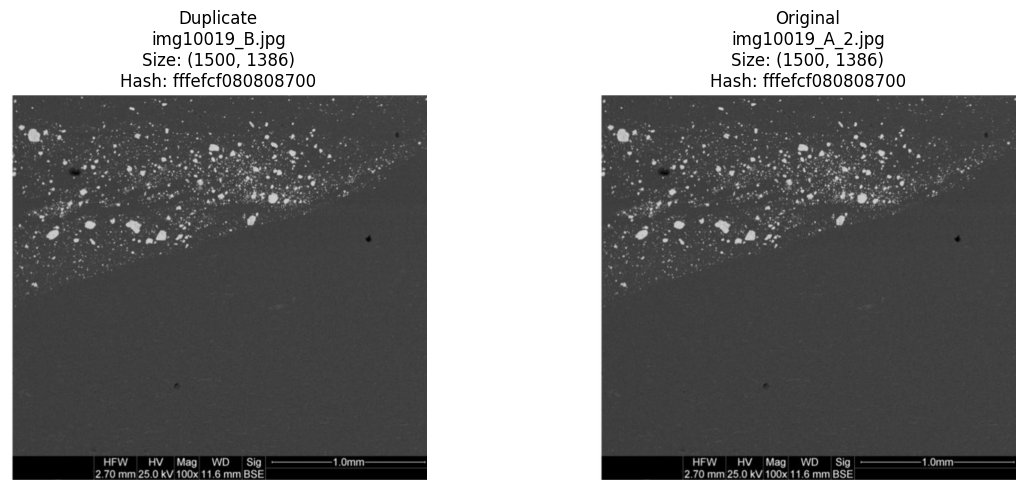

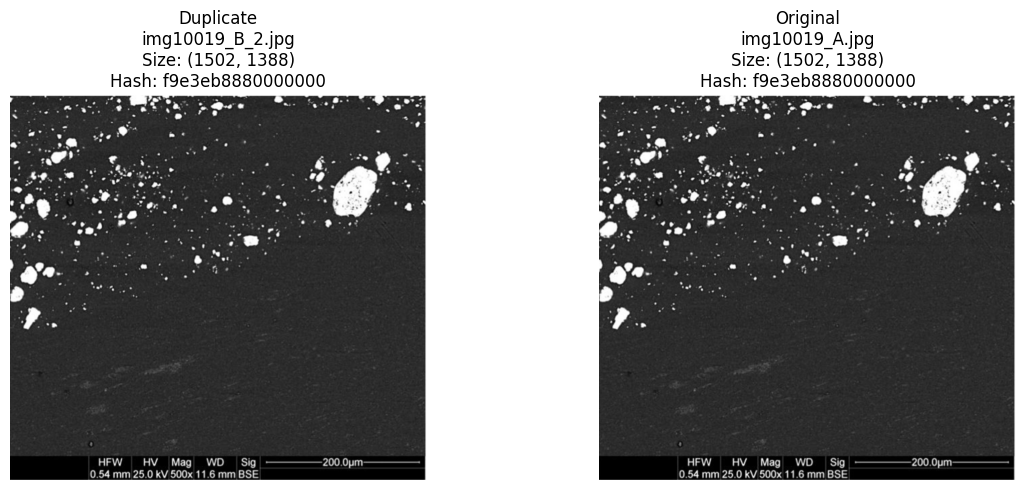

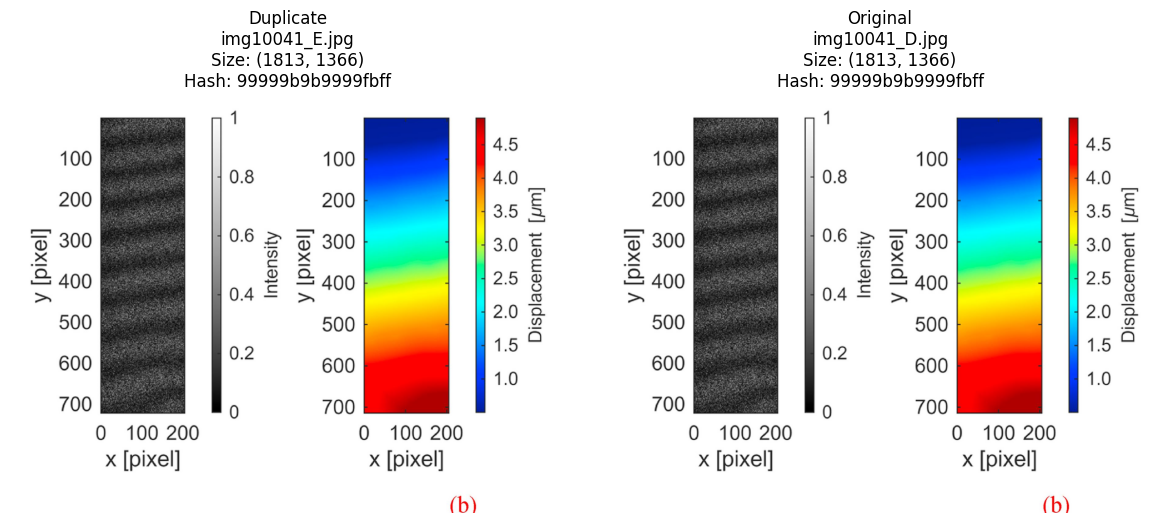

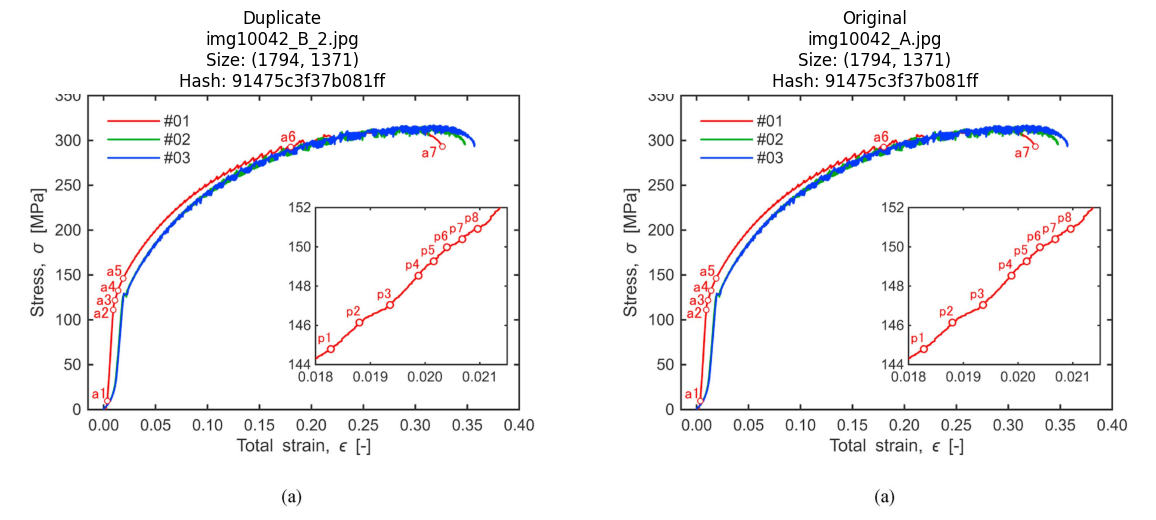

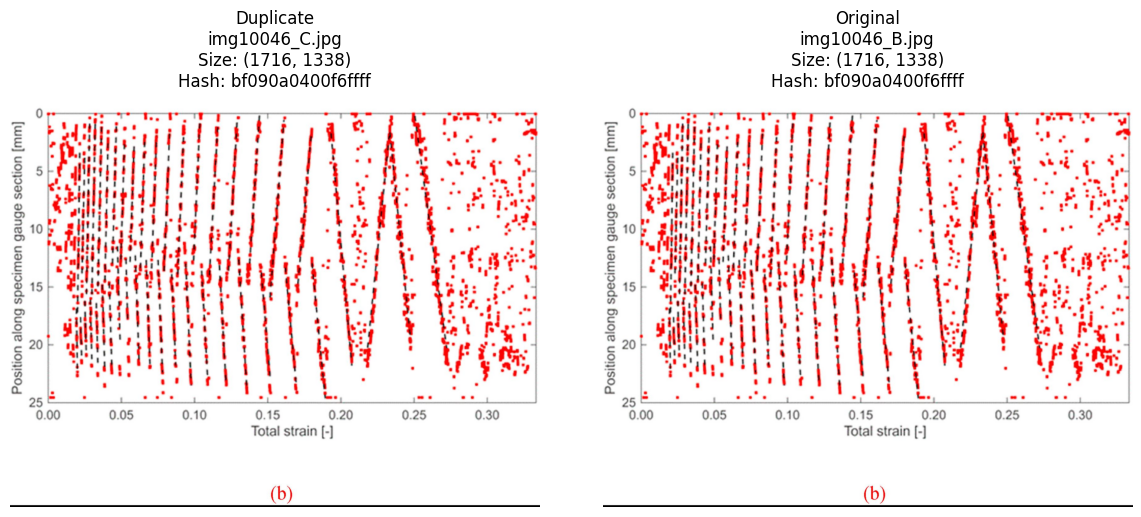

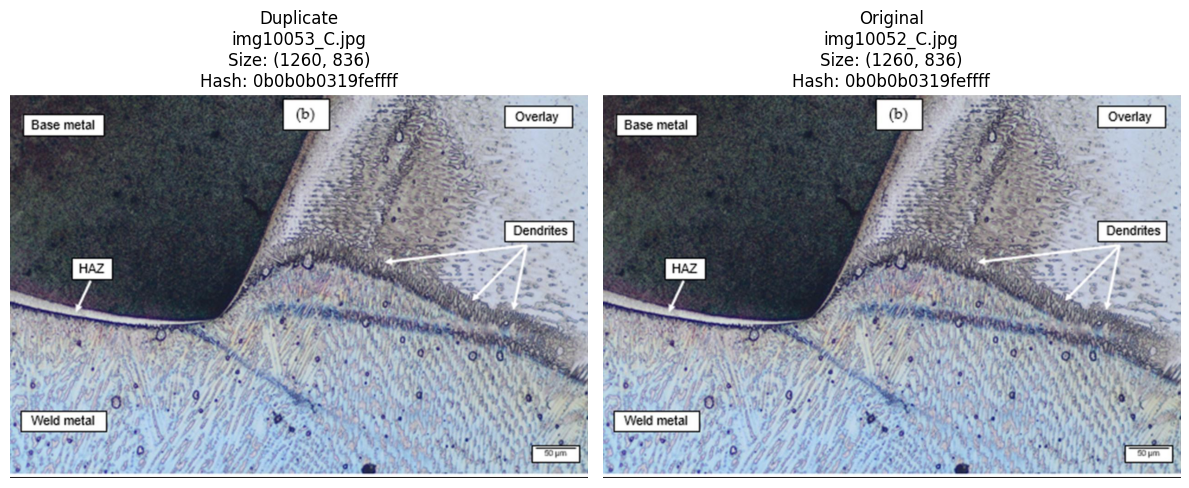

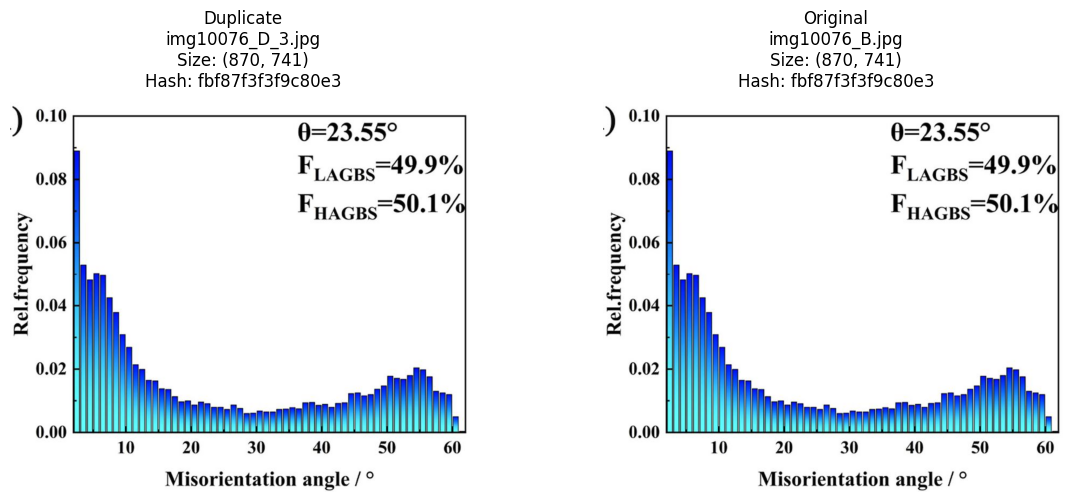

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import imagehash

for dup_path, orig_path in duplicates[:10]:

    dup_img = Image.open(dup_path)
    orig_img = Image.open(orig_path)

    dup_hash = imagehash.average_hash(dup_img)
    orig_hash = imagehash.average_hash(orig_img)

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    axes[0].imshow(dup_img, cmap='gray')
    axes[0].set_title(
        f"Duplicate\n"
        f"{dup_path.name}\n"
        f"Size: {dup_img.size}\n"
        f"Hash: {dup_hash}"
    )
    axes[0].axis("off")

    axes[1].imshow(orig_img, cmap='gray')
    axes[1].set_title(
        f"Original\n"
        f"{orig_path.name}\n"
        f"Size: {orig_img.size}\n"
        f"Hash: {orig_hash}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

remove the duplicates to the duplicates_removed/ folder

In [12]:
from pathlib import Path
import shutil

# destination folder
duplicate_dir = Path("../data/duplicates_removed")

duplicate_dir.mkdir(parents=True, exist_ok=True)

for dup_path, orig_path in duplicates:

    try:

        destination = duplicate_dir / dup_path.name

        # avoid overwriting
        counter = 1

        while destination.exists():

            destination = (
                duplicate_dir /
                f"{dup_path.stem}_{counter}{dup_path.suffix}"
            )

            counter += 1

        # move duplicate
        shutil.move(str(dup_path), str(destination))

        print(f"Moved duplicate: {dup_path.name}")

    except Exception as e:

        print(f"Error moving {dup_path}: {e}")

Moved duplicate: img10011_E.jpg
Moved duplicate: img10016_E_2.jpg
Moved duplicate: img10016_F.jpg
Moved duplicate: img10019_B.jpg
Moved duplicate: img10019_B_2.jpg
Moved duplicate: img10041_E.jpg
Moved duplicate: img10042_B_2.jpg
Moved duplicate: img10046_C.jpg
Moved duplicate: img10053_C.jpg
Moved duplicate: img10076_D_3.jpg
Moved duplicate: img10076_D_4.jpg
Moved duplicate: img10087_D.jpg
Moved duplicate: img10091_B_3.jpg
Moved duplicate: img10098_E_2.jpg
Moved duplicate: img10099_G.jpg
Moved duplicate: img10099_G_2.jpg
Moved duplicate: img10099_L.jpg
Moved duplicate: img10105_E.jpg
Moved duplicate: img10112_D.jpg
Moved duplicate: img10112_I.jpg
Moved duplicate: img10124_D.jpg
Moved duplicate: img10124_I.jpg
Moved duplicate: img10124_I_2.jpg
Moved duplicate: img10127_I.jpg
Moved duplicate: img10136_F.jpg
Moved duplicate: img10136_F_2.jpg
Moved duplicate: img10142_B.jpg
Moved duplicate: img1015_B_2.jpg
Moved duplicate: img10187_B_2.jpg
Moved duplicate: img10187_G.jpg
Moved duplicate: 

Remove Extremely Small Images

In [13]:
from pathlib import Path
from PIL import Image
import shutil

# minimum allowed size
MIN_WIDTH = 128
MIN_HEIGHT = 128

# folders
raw_dir = Path("data/raw")
small_dir = Path("data/small_images_removed")

small_dir.mkdir(parents=True, exist_ok=True)

# allowed image formats
valid_ext = [".png", ".jpg", ".jpeg", ".tif", ".bmp"]

# collect image paths
image_paths = [
    p for p in raw_dir.glob("**/*")
    if p.suffix.lower() in valid_ext
]

removed_count = 0

for path in image_paths:

    try:

        img = Image.open(path)

        width, height = img.size

        # check small image
        if width < MIN_WIDTH or height < MIN_HEIGHT:

            destination = small_dir / path.name

            # avoid overwrite
            counter = 1

            while destination.exists():

                destination = (
                    small_dir /
                    f"{path.stem}_{counter}{path.suffix}"
                )

                counter += 1

            # move small image
            shutil.move(str(path), str(destination))

            removed_count += 1

            print(
                f"Moved small image: {path.name} "
                f"({width}x{height})"
            )

    except Exception as e:

        print(f"Error with {path}: {e}")

print(f"\nTotal small images moved: {removed_count}")
    


Total small images moved: 0
